8. Practice training a deep neural network on the CIFAR10 image
dataset:


a. Load CIFAR10 just like you loaded the FashionMNIST
dataset in Chapter 10, but using
torchvision.datasets.CIFAR10 instead of
FashionMNIST. The dataset is composed of 60,000 32
× 32–pixel color images (50,000 for training, 10,000 for
testing) with 10 classes.

In [22]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


@torch.inference_mode()
def cifar_train_mean_std(train_ds, batch_size: int = 256):
    """Per-channel mean and std over the training set, shape (3,) each.

    Aggregates across all pixels in each channel (not per-pixel spatial stats).
    """
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    ch_sum = torch.zeros(3)
    ch_sq_sum = torch.zeros(3)
    num_pixels = 0  # total count of (H×W) positions × batch, per channel
    for x, _ in loader:
        # x: (B, C, H, W)
        ch_sum += x.sum(dim=(0, 2, 3))
        ch_sq_sum += (x * x).sum(dim=(0, 2, 3))
        num_pixels += x.size(0) * x.size(2) * x.size(3)
    mean = ch_sum / num_pixels
    var = ch_sq_sum / num_pixels - mean * mean
    std = torch.sqrt(var.clamp_min(1e-12))
    return mean, std


# CIFAR-10: 50k train / 10k test, 32×32 RGB, 10 classes
data_dir = "data"  # or "./data"

# Stats from full training split only; Normalize broadcasts (3,) over H,W.
_base_tf = transforms.ToTensor()
_raw_train_for_stats = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=True,
    transform=_base_tf,
)
train_mean, train_std = cifar_train_mean_std(_raw_train_for_stats)
assert train_mean.shape == (3,) and train_std.shape == (3,)
print("Per-channel train mean:", train_mean.tolist())
print("Per-channel train std: ", train_std.tolist())

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist()),
    ]
)

full_train_ds = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=False,
    transform=transform,
)
test_ds = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=False,
    transform=transform,
)

# Hold out part of the 50k training images for validation (e.g. early stopping).
val_fraction = 0.1
n_full = len(full_train_ds)
n_val = int(n_full * val_fraction)
n_train_split = n_full - n_val
g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_train_ds, [n_train_split, n_val], generator=g)

batch_size = 64
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

Per-channel train mean: [0.4913996458053589, 0.48215845227241516, 0.4465310275554657]
Per-channel train std:  [0.2470323145389557, 0.24348507821559906, 0.26158758997917175]


 Build a DNN with 20 hidden layers of 100 neurons each
(that’s too many, but it’s the point of this exercise). Use
He initialization and the Swish activation function (using
nn.SiLU). Since this is a classification task, you will
need an output layer with one neuron per class.

In [ ]:
import torch
import torch.nn as nn


class DeepMLP(nn.Module):
    """20 hidden layers × 100 units; BN + SiLU; 10-class logits. Input: N×3×32×32."""

    def __init__(
        self,
        in_channels: int = 3,
        height: int = 32,
        width: int = 32,
        num_classes: int = 10,
        hidden: int = 100,
        num_hidden_layers: int = 20,
    ):
        super().__init__()
        in_features = in_channels * height * width

        # Batch norm after each hidden Linear (not on the final classifier layer).
        blocks = [
            nn.Flatten(),
            nn.Linear(in_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
        ]
        for _ in range(num_hidden_layers - 1):
            blocks += [nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.SiLU()]
        blocks.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*blocks)
        self._he_init()

    def _he_init(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = DeepMLP()

c. Using NAdam optimization and early stopping, train the
network on the CIFAR10 dataset. Remember to search for
the right learning rate each time you change the model’s
architecture or hyperparameters.

In [7]:
import copy
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = DeepMLP().to(device)
criterion = nn.CrossEntropyLoss()

# Search this when you change the model or other settings (e.g. try 3e-4, 1e-3, 1e-4).
lr = 1e-3
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)

max_epochs = 100
patience = 10  # stop if val loss does not improve for this many epochs
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0.0
    n_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        train_loss += loss.item() * bs
        n_train += bs
    train_loss /= n_train

    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            bs = xb.size(0)
            val_loss += loss.item() * bs
            n_val += bs
    val_loss /= n_val

    print(f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Optional: evaluate on test_loader
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
print(f"Test accuracy: {100.0 * correct / total:.2f}%")

Epoch   1  train_loss=1.9706  val_loss=1.9355
Epoch   2  train_loss=1.6742  val_loss=1.7338
Epoch   3  train_loss=1.5694  val_loss=1.6845
Epoch   4  train_loss=1.5004  val_loss=2.1536
Epoch   5  train_loss=1.4485  val_loss=1.8488
Epoch   6  train_loss=1.4001  val_loss=1.7793
Epoch   7  train_loss=1.3679  val_loss=1.5851
Epoch   8  train_loss=1.3258  val_loss=1.5275
Epoch   9  train_loss=1.2925  val_loss=1.7718
Epoch  10  train_loss=1.2546  val_loss=2.0533
Epoch  11  train_loss=1.2308  val_loss=1.5422
Epoch  12  train_loss=1.1927  val_loss=1.5477
Epoch  13  train_loss=1.1715  val_loss=1.5424
Epoch  14  train_loss=1.1391  val_loss=1.5845
Epoch  15  train_loss=1.1150  val_loss=1.5504
Epoch  16  train_loss=1.0870  val_loss=1.4494
Epoch  17  train_loss=1.0686  val_loss=1.4899
Epoch  18  train_loss=1.0413  val_loss=1.5524
Epoch  19  train_loss=1.0238  val_loss=1.4977
Epoch  20  train_loss=1.0035  val_loss=1.4295
Epoch  21  train_loss=0.9790  val_loss=1.5842
Epoch  22  train_loss=0.9709  val_

d. Now try adding batch norm and compare the learning
curves: is it converging faster than before? Does it
produce a better model? How does it affect training
speed?

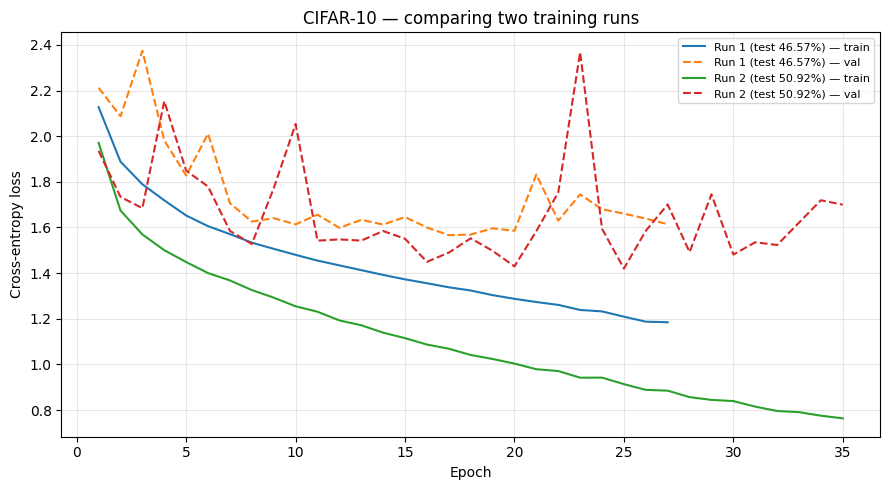

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

df1 = pd.read_csv("q8_cifar10_training_log.csv")
df2 = pd.read_csv("q8_cifar10_training_log_run2.csv")

label1 = f"Run 1 (test {df1['test_accuracy_pct'].iloc[0]:.2f}%)"
label2 = f"Run 2 (test {df2['test_accuracy_pct'].iloc[0]:.2f}%)"

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df1["epoch"], df1["train_loss"], label=f"{label1} — train", linestyle="-", linewidth=1.5)
ax.plot(df1["epoch"], df1["val_loss"], label=f"{label1} — val", linestyle="--", linewidth=1.5)

ax.plot(df2["epoch"], df2["train_loss"], label=f"{label2} — train", linestyle="-", linewidth=1.5)
ax.plot(df2["epoch"], df2["val_loss"], label=f"{label2} — val", linestyle="--", linewidth=1.5)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("CIFAR-10 — comparing two training runs")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

BatchNorm stabilizes training and helps optimization


Without BatchNorm: 
Higher training loss
Slower convergence
Smoother but worse validation performance
Lower final accuracy

With BatchNorm:
Lower training loss
Faster and more effective learning
Noisier (spiky) validation loss
Better generalization and higher accuracy



Try replacing batch norm with SELU, and make the
necessary adjustments to ensure the network self-
normalizes (i.e., standardize the input features, use LeCun
normal initialization, make sure the DNN contains only a
sequence of dense layers, etc.).

In [23]:
import math

import torch.nn as nn


class DeepMLP(nn.Module):
    """20×100 dense stack + SELU; 10 logits. Standardize inputs in the data pipeline."""

    def __init__(
        self,
        in_channels: int = 3,
        height: int = 32,
        width: int = 32,
        num_classes: int = 10,
        hidden: int = 100,
        num_hidden_layers: int = 20,
    ):
        super().__init__()
        in_features = in_channels * height * width

        blocks: list[nn.Module] = [
            nn.Flatten(),
            nn.Linear(in_features, hidden),
            nn.SELU(),
        ]
        for _ in range(num_hidden_layers - 1):
            blocks += [nn.Linear(hidden, hidden), nn.SELU()]
        blocks.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*blocks)
        self._lecun_normal_init()

    def _lecun_normal_init(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                fan_in = m.weight.shape[1]
                std = 1.0 / math.sqrt(fan_in)
                nn.init.normal_(m.weight, 0.0, std)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = DeepMLP()

In [24]:
import copy
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = DeepMLP().to(device)
criterion = nn.CrossEntropyLoss()

# Search this when you change the model or other settings (e.g. try 3e-4, 1e-3, 1e-4).
lr = 1e-3
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)

max_epochs = 100
patience = 10  # stop if val loss does not improve for this many epochs
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0.0
    n_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        train_loss += loss.item() * bs
        n_train += bs
    train_loss /= n_train

    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            bs = xb.size(0)
            val_loss += loss.item() * bs
            n_val += bs
    val_loss /= n_val

    print(f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Optional: evaluate on test_loader
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
print(f"Test accuracy: {100.0 * correct / total:.2f}%")

Epoch   1  train_loss=1.9245  val_loss=1.9843
Epoch   2  train_loss=1.7177  val_loss=1.7279
Epoch   3  train_loss=1.6127  val_loss=1.7544
Epoch   4  train_loss=1.5433  val_loss=1.5761
Epoch   5  train_loss=1.4823  val_loss=1.6595
Epoch   6  train_loss=1.4381  val_loss=1.6382
Epoch   7  train_loss=1.3876  val_loss=1.5646
Epoch   8  train_loss=1.3546  val_loss=1.6197
Epoch   9  train_loss=1.3221  val_loss=1.6243
Epoch  10  train_loss=1.2911  val_loss=1.5067
Epoch  11  train_loss=1.2583  val_loss=1.4790
Epoch  12  train_loss=1.2292  val_loss=1.5153
Epoch  13  train_loss=1.1983  val_loss=1.5646
Epoch  14  train_loss=1.1831  val_loss=1.5153
Epoch  15  train_loss=1.1614  val_loss=1.5267
Epoch  16  train_loss=1.1412  val_loss=1.5165
Epoch  17  train_loss=1.1232  val_loss=1.4816
Epoch  18  train_loss=1.0969  val_loss=1.5012
Epoch  19  train_loss=1.0799  val_loss=1.5451
Epoch  20  train_loss=1.0693  val_loss=1.5762
Epoch  21  train_loss=1.0370  val_loss=1.6009
Early stopping at epoch 21 (best v

Using alpha dropout with SeLU, alpha dropout works compared to regular dropout becuase it preserves normality.

In [25]:
import math

import torch.nn as nn


class DeepMLP(nn.Module):
    """20×100 dense stack + SELU + AlphaDropout; 10 logits. Standardize inputs in the data pipeline."""

    def __init__(
        self,
        in_channels: int = 3,
        height: int = 32,
        width: int = 32,
        num_classes: int = 10,
        hidden: int = 100,
        num_hidden_layers: int = 20,
        dropout_p: float = 0.1,
    ):
        super().__init__()
        in_features = in_channels * height * width

        blocks: list[nn.Module] = [
            nn.Flatten(),
            nn.Linear(in_features, hidden),
            nn.SELU(),
            nn.AlphaDropout(p=dropout_p),
        ]
        for _ in range(num_hidden_layers - 1):
            blocks += [
                nn.Linear(hidden, hidden),
                nn.SELU(),
                nn.AlphaDropout(p=dropout_p),
            ]
        blocks.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*blocks)
        self._lecun_normal_init()

    def _lecun_normal_init(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                fan_in = m.weight.shape[1]
                std = 1.0 / math.sqrt(fan_in)
                nn.init.normal_(m.weight, 0.0, std)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = DeepMLP(dropout_p=0.1)

In [26]:
import copy
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = DeepMLP().to(device)
criterion = nn.CrossEntropyLoss()

# Search this when you change the model or other settings (e.g. try 3e-4, 1e-3, 1e-4).
lr = 1e-3
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)

max_epochs = 100
patience = 10  # stop if val loss does not improve for this many epochs
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0.0
    n_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        bs = xb.size(0)
        train_loss += loss.item() * bs
        n_train += bs
    train_loss /= n_train

    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            bs = xb.size(0)
            val_loss += loss.item() * bs
            n_val += bs
    val_loss /= n_val

    print(f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# Optional: evaluate on test_loader
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
print(f"Test accuracy: {100.0 * correct / total:.2f}%")

Epoch   1  train_loss=2.1231  val_loss=3.4544
Epoch   2  train_loss=1.9641  val_loss=7.4589
Epoch   3  train_loss=1.8948  val_loss=7.0832
Epoch   4  train_loss=1.8461  val_loss=5.8335
Epoch   5  train_loss=1.8218  val_loss=5.9151
Epoch   6  train_loss=1.7919  val_loss=7.7082
Epoch   7  train_loss=1.7727  val_loss=6.7461
Epoch   8  train_loss=1.7662  val_loss=5.2076
Epoch   9  train_loss=1.7237  val_loss=7.5432
Epoch  10  train_loss=1.7153  val_loss=6.3170
Epoch  11  train_loss=1.6949  val_loss=6.5464
Early stopping at epoch 11 (best val_loss=3.4544)
Test accuracy: 22.53%


MC dropout for inference

In [27]:
import torch
@torch.inference_mode()
def test_accuracy_mc_dropout(model, loader, device, n_samples: int = 20):
    """MC dropout: multiple noisy forwards at p from the module; average logits."""
    model.train()  # required: dropout must stay ON
    correct = 0
    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits_avg = torch.stack([model(xb) for _ in range(n_samples)], dim=0).mean(0)
        pred = logits_avg.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return 100.0 * correct / total
# Example (after you load best weights):
device = next(model.parameters()).device
acc_mc = test_accuracy_mc_dropout(model, test_loader, device, n_samples=50)
print(f"Test accuracy (MC dropout, n=20, p=0.1 via model): {acc_mc:.2f}%")

Test accuracy (MC dropout, n=20, p=0.1 via model): 23.10%


Trying 1cycle scheduling

1-cycle = increase LR then decrease it to train faster and better



In [20]:
import copy

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import OneCycleLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

model = DeepMLP().to(device)
criterion = nn.CrossEntropyLoss()

# Peak LR for 1cycle; search this when you change the model / dropout / batch size.
max_lr = 1e-3

optimizer = torch.optim.NAdam(
    model.parameters(),
    lr=max_lr / 25.0,  # sane default start vs OneCycle's div_factor (scheduler still drives the curve)
)

max_epochs = 100
patience = 10

scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    steps_per_epoch=len(train_loader),
    epochs=max_epochs,
    pct_start=0.3,
    div_factor=25.0,
    final_div_factor=1e4,
    anneal_strategy="cos",
)

best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0.0
    n_train = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        scheduler.step()  # 1cycle: once per batch

        bs = xb.size(0)
        train_loss += loss.item() * bs
        n_train += bs
    train_loss /= n_train

    model.eval()
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            bs = xb.size(0)
            val_loss += loss.item() * bs
            n_val += bs
    val_loss /= n_val

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  lr={current_lr:.2e}"
    )

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch   1  train_loss=2.4990  val_loss=2.6352  lr=4.26e-05
Epoch   2  train_loss=2.2959  val_loss=2.3353  lr=5.05e-05
Epoch   3  train_loss=2.2112  val_loss=2.2911  lr=6.35e-05
Epoch   4  train_loss=2.1473  val_loss=2.1873  lr=8.15e-05
Epoch   5  train_loss=2.0703  val_loss=2.1437  lr=1.04e-04
Epoch   6  train_loss=2.0032  val_loss=2.1138  lr=1.32e-04
Epoch   7  train_loss=1.9691  val_loss=2.0895  lr=1.63e-04
Epoch   8  train_loss=1.9313  val_loss=2.1895  lr=1.99e-04
Epoch   9  train_loss=1.8946  val_loss=2.8284  lr=2.38e-04
Epoch  10  train_loss=1.8826  val_loss=3.4926  lr=2.80e-04
Epoch  11  train_loss=1.8257  val_loss=3.5533  lr=3.25e-04
Epoch  12  train_loss=1.7933  val_loss=4.2700  lr=3.72e-04
Epoch  13  train_loss=1.7648  val_loss=4.0337  lr=4.20e-04
Epoch  14  train_loss=1.7334  val_loss=4.8651  lr=4.70e-04
Epoch  15  train_loss=1.7040  val_loss=5.0667  lr=5.20e-04
Epoch  16  train_loss=1.6775  val_loss=5.3138  lr=5.70e-04
Epoch  17  train_loss=1.6751  val_loss=5.1589  lr=6.20e-

In [21]:
import torch
import torch.nn as nn
def test_loss_and_accuracy(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_loss = 0.0
    total = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item()
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    avg_loss = total_loss / total
    acc_pct = 100.0 * correct / total
    return avg_loss, acc_pct
device = next(model.parameters()).device
test_loss, test_acc = test_loss_and_accuracy(model, test_loader, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2f}%")

Test loss: 2.0680
Test accuracy: 29.44%
